In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6593122dbc253272a6ebfca72103e2ab'

In [2]:
!kaggle datasets list

ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                   Social Media Impact on Teen Mental Health               16190  2026-04-05 08:04:21.823000          28126        606                1  
aminasalamt/amazon-tech-trends-and-sales-insights-2026           Amazon Tech Trends & Sales Insights 2026                 1997  2026-05-13 13:49:16.070000            469         24                1  
shambhurajejagadale/student-performance-prediction-dataset       Student Performance Prediction Dataset                  84282  2026-05-09 15:49:58.877000           1220         35                1  


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content

/content


In [5]:
!mkdir -p /content/drive/MyDrive/medical_project

In [6]:
%cd /content/drive/MyDrive/medical_project

/content/drive/MyDrive/medical_project


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/medical_model_checkpoint.keras',
    save_best_only=True,
    monitor='val_loss')

In [23]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [24]:
import shutil

# Remove the destination directory if it exists to ensure a clean extraction
if os.path.exists('chest_xray'):
    shutil.rmtree('chest_xray')

!unzip -q chest-xray-pneumonia.zip -d chest_xray

In [10]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [68]:
# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p '/content/brain_mri' --unzip

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 168MB/s]



In [69]:
# Verify Training is there
!ls '/content/brain_mri'
!ls '/content/brain_mri/Training'

glioma	meningioma  notumor  pituitary


In [70]:
# Save to Drive immediately so this never happens again
!cp -r '/content/brain_mri/Training' '/content/drive/MyDrive/medical_project/brain_mri/Training'

In [12]:
import shutil

# Remove the destination directory if it exists to ensure a clean extraction
if os.path.exists('brain_mri'):
    shutil.rmtree('brain_mri')

!unzip -q brain-tumor-mri-dataset.zip -d brain_mri

In [25]:
import os

base_path = "/content/drive/MyDrive/medical_project/medical_dataset"

folders = [
    "pneumonia/NORMAL",
    "pneumonia/PNEUMONIA",

    "brain_tumor/glioma",
    "brain_tumor/meningioma",
    "brain_tumor/pituitary",
    "brain_tumor/notumor"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Unified dataset folders created successfully")

Unified dataset folders created successfully


In [67]:
import os

base = "/content/drive/MyDrive/medical_project/medical_dataset"

for root, dirs, files in os.walk(base):

    if len(files) > 0:
        print(root, " ---> ", len(files), "images")

/content/drive/MyDrive/medical_project/medical_dataset/pneumonia/NORMAL  --->  1341 images
/content/drive/MyDrive/medical_project/medical_dataset/pneumonia/PNEUMONIA  --->  3875 images
/content/drive/MyDrive/medical_project/medical_dataset/brain_tumor/glioma  --->  1400 images
/content/drive/MyDrive/medical_project/medical_dataset/brain_tumor/meningioma  --->  1400 images
/content/drive/MyDrive/medical_project/medical_dataset/brain_tumor/pituitary  --->  1400 images
/content/drive/MyDrive/medical_project/medical_dataset/brain_tumor/notumor  --->  1400 images


Preparing chest xray model

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model , Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, GlobalMaxPool2D

In [15]:
conv_base = DenseNet121(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
for i, layer in enumerate(conv_base.layers):
    print(i, layer.name)

0 input_layer
1 zero_padding2d
2 conv1_conv
3 conv1_bn
4 conv1_relu
5 zero_padding2d_1
6 pool1
7 conv2_block1_0_bn
8 conv2_block1_0_relu
9 conv2_block1_1_conv
10 conv2_block1_1_bn
11 conv2_block1_1_relu
12 conv2_block1_2_conv
13 conv2_block1_concat
14 conv2_block2_0_bn
15 conv2_block2_0_relu
16 conv2_block2_1_conv
17 conv2_block2_1_bn
18 conv2_block2_1_relu
19 conv2_block2_2_conv
20 conv2_block2_concat
21 conv2_block3_0_bn
22 conv2_block3_0_relu
23 conv2_block3_1_conv
24 conv2_block3_1_bn
25 conv2_block3_1_relu
26 conv2_block3_2_conv
27 conv2_block3_concat
28 conv2_block4_0_bn
29 conv2_block4_0_relu
30 conv2_block4_1_conv
31 conv2_block4_1_bn
32 conv2_block4_1_relu
33 conv2_block4_2_conv
34 conv2_block4_concat
35 conv2_block5_0_bn
36 conv2_block5_0_relu
37 conv2_block5_1_conv
38 conv2_block5_1_bn
39 conv2_block5_1_relu
40 conv2_block5_2_conv
41 conv2_block5_concat
42 conv2_block6_0_bn
43 conv2_block6_0_relu
44 conv2_block6_1_conv
45 conv2_block6_1_bn
46 conv2_block6_1_relu
47 conv2_blo

In [17]:
conv_base.trainable = True

for layer in conv_base.layers:
    layer.trainable = False

for layer in conv_base.layers[-50:]:
    layer.trainable = True

for layer in conv_base.layers:
    print(layer.name, layer.trainable)

input_layer False
zero_padding2d False
conv1_conv False
conv1_bn False
conv1_relu False
zero_padding2d_1 False
pool1 False
conv2_block1_0_bn False
conv2_block1_0_relu False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_concat False
conv2_block2_0_bn False
conv2_block2_0_relu False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_concat False
conv2_block3_0_bn False
conv2_block3_0_relu False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_concat False
conv2_block4_0_bn False
conv2_block4_0_relu False
conv2_block4_1_conv False
conv2_block4_1_bn False
conv2_block4_1_relu False
conv2_block4_2_conv False
conv2_block4_concat False
conv2_block5_0_bn False
conv2_block5_0_relu False
conv2_block5_1_conv False
conv2_block5_1_bn False
conv2_block5_1_relu False
conv2_block5_2_conv False
conv2_block5_

In [18]:
model = Sequential()
model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(Dropout(0.6)) # Increased dropout rate
model.add(Dense(1, activation='sigmoid', kernel_regularizer=keras.regularizers.l2(0.001)))

In [19]:
conv_base.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 1,075,648 (4.10 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

Data augumentaion

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator , load_img , img_to_array, array_to_img

In [28]:
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.5,
    zoom_range = 0.5,
    horizontal_flip = True,
    vertical_flip = True
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/medical_project/chest_xray/chest_xray/train',
    target_size = (224,224),
    batch_size = batch_size,
    class_mode = 'binary'
)

validate_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/medical_project/chest_xray/chest_xray/test',
    target_size = (224,224),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [27]:
import os

# List the contents of the unzipped chest_xray directory to find the correct path
print(os.listdir('/content/drive/MyDrive/medical_project/chest_xray'))

['chest_xray']


In [29]:
import os

# List the contents of the nested chest_xray directory
print(os.listdir('/content/drive/MyDrive/medical_project/chest_xray/chest_xray'))

['__MACOSX', 'chest_xray', 'test', 'train', 'val']


In [30]:
model.compile(optimizer= 'adam', loss = 'binary_crossentropy', metrics = ['accuracy', 'precision', 'recall'])

In [31]:
# Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
     monitor="val_loss",
    min_delta=0.00001,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [32]:
history = model.fit(
    train_generator,
    epochs = 20,
    validation_data = validate_generator,
    callbacks = [early_stopping]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8942 - loss: 0.4731 - precision: 0.9268 - recall: 0.9311 - val_accuracy: 0.9135 - val_loss: 0.3468 - val_precision: 0.9398 - val_recall: 0.9205
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 873ms/step - accuracy: 0.9331 - loss: 0.3041 - precision: 0.9589 - recall: 0.9507 - val_accuracy: 0.8782 - val_loss: 0.5923 - val_precision: 0.8520 - val_recall: 0.9744
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 858ms/step - accuracy: 0.9463 - loss: 0.2479 - precision: 0.9665 - recall: 0.9610 - val_accuracy: 0.9215 - val_loss: 0.3698 - val_precision: 0.9031 - val_recall: 0.9795
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 851ms/step - accuracy: 0.9471 - loss: 0.2225 - precision: 0.9673 - recall: 0.9613 - val_accuracy: 0.9119 - val_loss: 0.3732 - val_precision: 0.8851 - val_recall: 0.9872
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 843ms/step - accuracy: 0.9450 - loss: 0.2074 - precision: 0.9633 - recall: 0.9626 - val_accuracy: 0.91

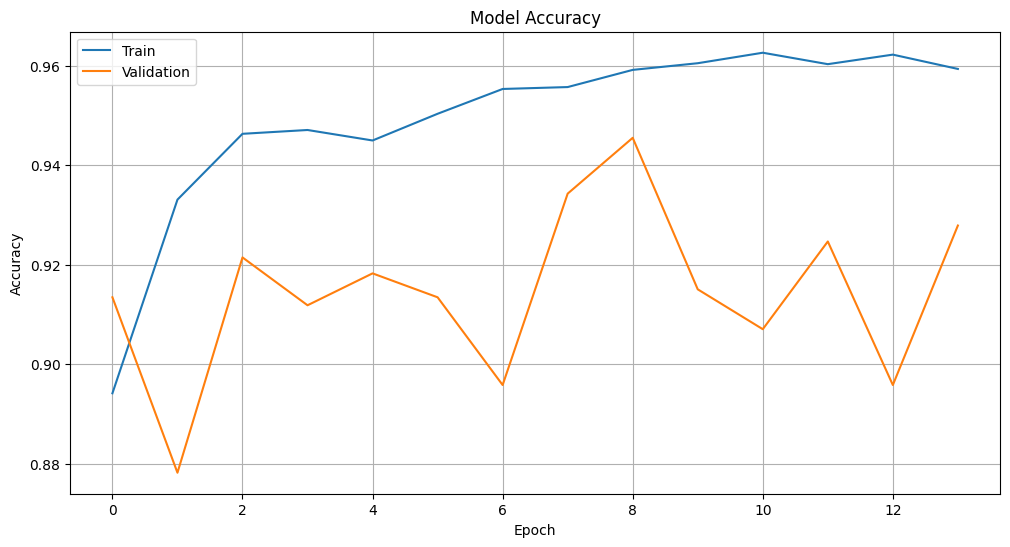

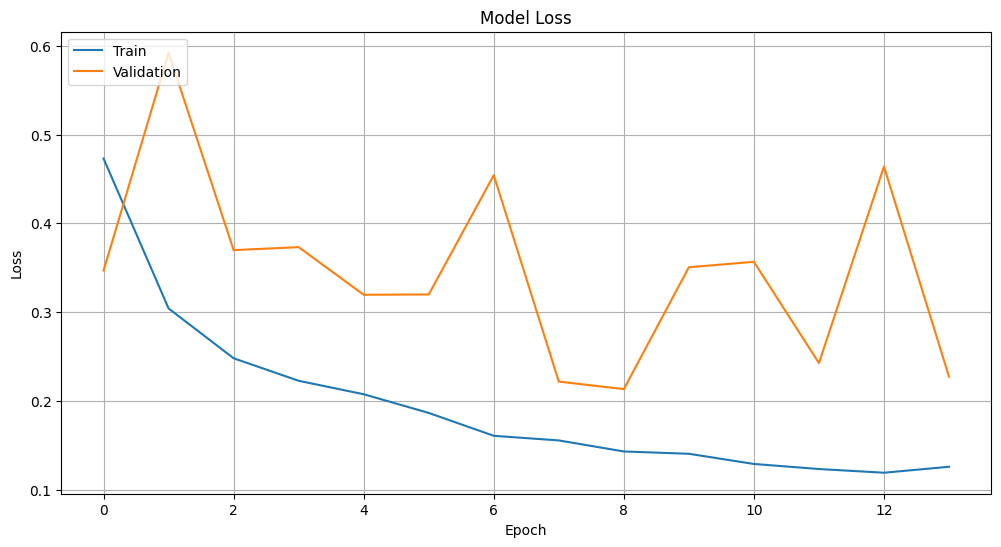

In [33]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [34]:
model.compile(optimizer= 'adam', loss = 'binary_crossentropy', metrics = ['accuracy', 'precision', 'recall'])
test_loss, test_acc, test_precision, test_recall = model.evaluate(validate_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9279 - loss: 0.2271 - precision: 0.9238 - recall: 0.9641
Test Accuracy: 0.9279
Test Loss:     0.2271


Testing model pred

In [35]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input
import numpy as np

In [40]:
img_path = '/content/drive/MyDrive/medical_project/chest_xray/chest_xray/test/NORMAL/IM-0007-0001.jpeg'

In [41]:
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [42]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[0.00040907]]


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

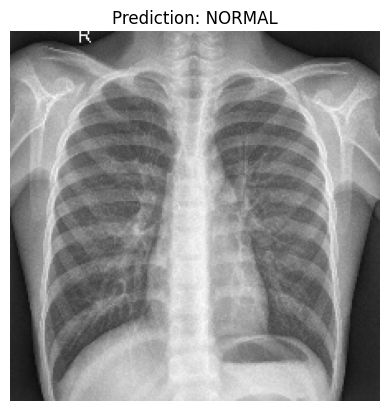

In [43]:
import matplotlib.pyplot as plt

# Assuming the model outputs the probability of PNEUMONIA (class index 1).
# And assuming 'NORMAL' is class index 0 and 'PNEUMONIA' is class index 1 (alphabetical order).
class_labels = ['NORMAL', 'PNEUMONIA']

# Interpret the prediction (e.g., [[0.6155932]])
pneumonia_probability = prediction[0][0]

if pneumonia_probability > 0.5:
    corrected_predicted_class = class_labels[1] # PNEUMONIA
else:
    corrected_predicted_class = class_labels[0] # NORMAL

plt.imshow(img)
plt.title(f"Prediction: {corrected_predicted_class}")
plt.axis("off")

Preparing brain mri model

In [44]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,GlobalAveragePooling2D, Dropout
from keras.applications import EfficientNetV2B3

Load data

In [63]:
!cp -r '/content/drive/MyDrive/medical_project/brain_mri' '/content/brain_mri'

In [64]:
!cp -r '/content/drive/MyDrive/medical_project/brain_mri/Training' '/content/brain_mri/Training'

cp: cannot stat '/content/drive/MyDrive/medical_project/brain_mri/Training': No such file or directory


In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet_v2.preprocess_input,
    # rescale = 1./255,
    shear_range = 0.5,
    zoom_range = 0.5,
    horizontal_flip = True,
    vertical_flip = True
)

test_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet_v2.preprocess_input,
    # rescale = 1./255
)
train_generator = train_datagen.flow_from_directory(
    '/content/brain_mri//Training',
    target_size = (300,300),
    batch_size = 16,
    class_mode = 'categorical',

)
validate_generator = test_datagen.flow_from_directory(
    '/content//brain_mri/Testing',
    target_size = (300,300),
    batch_size = 16,
    class_mode = 'categorical',


)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [72]:
# Brain tumor dataset is imbalanced — meningioma has fewer samples
import numpy as np

class_counts = np.bincount(train_generator.classes)
for label, count in zip(train_generator.class_indices.keys(), class_counts):
    print(f"{label:15s}: {count} images")

glioma         : 1400 images
meningioma     : 1400 images
notumor        : 1400 images
pituitary      : 1400 images


In [73]:
# To check class imbalances
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


Train

In [74]:
conv_base = EfficientNetV2B3(
    weights = 'imagenet',
    include_top= False,
    input_shape = (300,300,3))

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [75]:
# Update img size
target_size = (300,300)

In [76]:
conv_base.trainable = True

In [77]:
from tensorflow.keras.models import Sequential

brain_mri_model = Sequential()
brain_mri_model.add(conv_base)
brain_mri_model.add(GlobalAveragePooling2D())
brain_mri_model.add(Dense(256, activation='relu' ))
brain_mri_model.add(Dropout(0.5))
brain_mri_model.add(Dense(4, activation='softmax'))

In [78]:
brain_mri_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,325,122 (50.83 MB)

 Trainable params: 13,215,906 (50.41 MB)

 Non-trainable params: 109,216 (426.62 KB)

In [79]:
print("Trainable weights:", len(brain_mri_model.trainable_weights))
print("Non-trainable weights:", len(brain_mri_model.non_trainable_weights))

Trainable weights: 364
Non-trainable weights: 176


Training

In [84]:
from tensorflow.keras.metrics import AUC
brain_mri_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy', AUC(name='auc')]
    # run_eagerly=True
)

In [85]:
# Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
     monitor="val_loss",
     patience = 7,
    #  min_delta = 0.00001,
    #  verbose = 1,
    #  mode = "auto",
    #  baseline = None,
     restore_best_weights = True
)

In [86]:
import tensorflow as tf

# Convert generators to tf.dataset and cache in RAM
train_dataset = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32)
    )
).cache()  # caches entire dataset in RAM after first epoch

validate_dataset = tf.data.Dataset.from_generator(
    lambda: validate_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32)
    )
).cache()

In [87]:
history = brain_mri_model.fit(train_generator,
          epochs=30,
          validation_data = validate_generator,
          callbacks = [early_stopping],
          class_weight=class_weight_dict
)

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 347s 509ms/step - accuracy: 0.8286 - auc: 0.9628 - loss: 0.4761 - val_accuracy: 0.9025 - val_auc: 0.9810 - val_loss: 0.3221
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 161s 460ms/step - accuracy: 0.9236 - auc: 0.9905 - loss: 0.2190 - val_accuracy: 0.9106 - val_auc: 0.9826 - val_loss: 0.3045
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 162s 462ms/step - accuracy: 0.9473 - auc: 0.9945 - loss: 0.1581 - val_accuracy: 0.9375 - val_auc: 0.9848 - val_loss: 0.2654
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 162s 462ms/step - accuracy: 0.9589 - auc: 0.9971 - loss: 0.1139 - val_accuracy: 0.9475 - val_auc: 0.9880 - val_loss: 0.2199
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 161s 459ms/step - accuracy: 0.9668 - auc: 0.9976 - loss: 0.0979 - val_accuracy: 0.9463 - val_auc: 0.9837 - val_loss: 0.2764
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 160s 456ms/step - accuracy: 0.9712 - auc: 0.9981 - loss: 0.0848 - val_accuracy: 0.9469 - val_auc: 0.9827 - val_loss: 0.2864
Epoch 7/30
350/3

checking validation

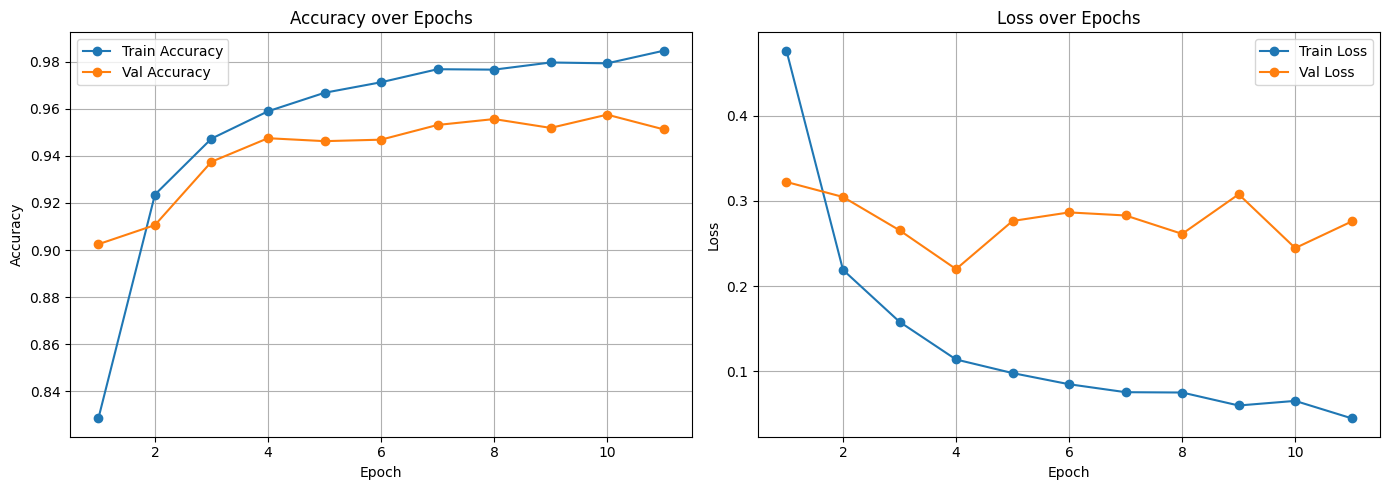

Final Train Accuracy : 0.9846
Final Val Accuracy   : 0.9513
Final Train Loss     : 0.0448
Final Val Loss       : 0.2758
Best Val Accuracy    : 0.9575 at epoch 10


In [88]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final numbers
print(f"Final Train Accuracy : {acc[-1]:.4f}")
print(f"Final Val Accuracy   : {val_acc[-1]:.4f}")
print(f"Final Train Loss     : {loss[-1]:.4f}")
print(f"Final Val Loss       : {val_loss[-1]:.4f}")
print(f"Best Val Accuracy    : {max(val_acc):.4f} at epoch {val_acc.index(max(val_acc))+1}")

In [90]:
# Check what the model actually predicts across the whole test set
import numpy as np

brain_class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Added this line

y_pred = np.argmax(brain_mri_model.predict(validate_generator), axis=1)
y_true = validate_generator.classes

# See prediction distribution
unique, counts = np.unique(y_pred, return_counts=True)
print("Prediction distribution:")
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({brain_class_labels[cls]}): {count} times")

print("\nActual distribution:")
unique_true, counts_true = np.unique(y_true, return_counts=True)
for cls, count in zip(unique_true, counts_true):
    print(f"  Class {cls} ({brain_class_labels[cls]}): {count} times")

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step
Prediction distribution:
  Class 0 (glioma): 342 times
  Class 1 (meningioma): 434 times
  Class 2 (notumor): 430 times
  Class 3 (pituitary): 394 times

Actual distribution:
  Class 0 (glioma): 400 times
  Class 1 (meningioma): 400 times
  Class 2 (notumor): 400 times
  Class 3 (pituitary): 400 times


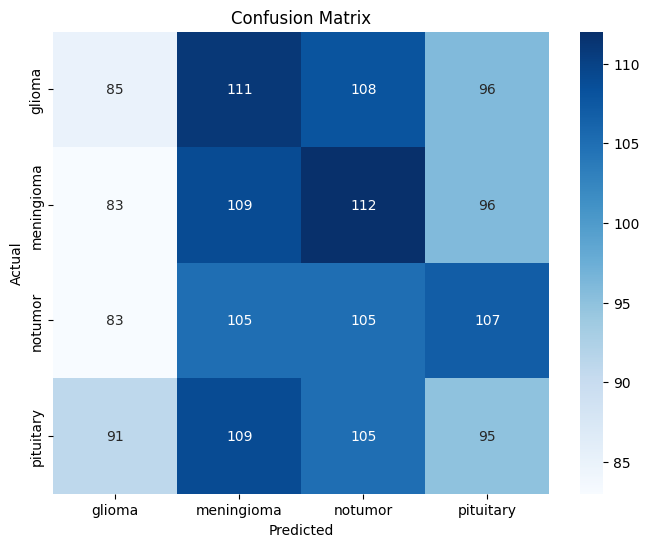

              precision    recall  f1-score   support

      glioma       0.25      0.21      0.23       400
  meningioma       0.25      0.27      0.26       400
     notumor       0.24      0.26      0.25       400
   pituitary       0.24      0.24      0.24       400

    accuracy                           0.25      1600
   macro avg       0.25      0.25      0.25      1600
weighted avg       0.25      0.25      0.25      1600



In [91]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

brain_class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=brain_class_labels,
            yticklabels=brain_class_labels,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_true, y_pred,
      target_names=brain_class_labels))

Testing prediction

In [92]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import efficientnet_v2
import matplotlib.pyplot as plt

brain_class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_brain_mri(img_path, model_to_use):
    # Load and preprocess
    img = image.load_img(img_path, target_size=(300, 300))
    img_array = image.img_to_array(img)
    img_array = efficientnet_v2.preprocess_input(img_array)  # must match training
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model_to_use.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions)
    predicted_class = brain_class_labels[predicted_idx]
    confidence = np.max(predictions) * 100

    # Plot
    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%",
              fontsize=14, fontweight='bold',
              color='green' if confidence > 70 else 'red')
    plt.show()

    # All probabilities
    print("\nAll class probabilities:")
    for label, prob in zip(brain_class_labels, predictions[0]):
        bar = '█' * int(prob * 40)
        print(f"  {label:15s}: {prob*100:.2f}%  {bar}")

    # Confidence warning
    if confidence < 70:
        print("\n Low confidence — consult a radiologist")

Actual class: glioma


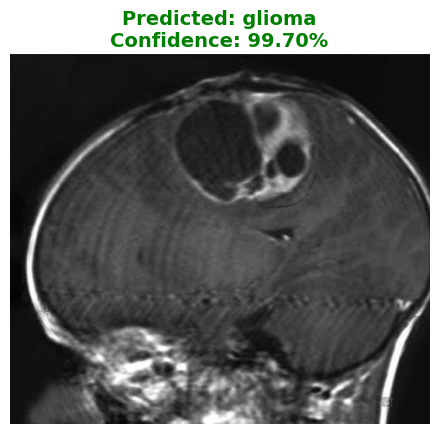


All class probabilities:
  glioma         : 99.70%  ███████████████████████████████████████
  meningioma     : 0.05%  
  notumor        : 0.20%  
  pituitary      : 0.05%  
Actual class: meningioma


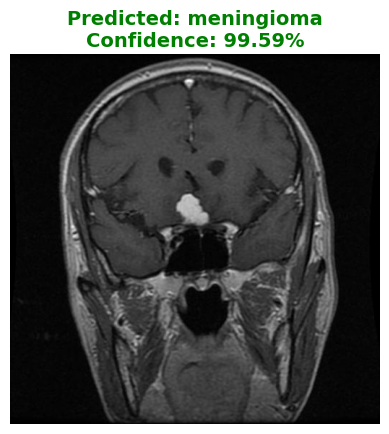


All class probabilities:
  glioma         : 0.07%  
  meningioma     : 99.59%  ███████████████████████████████████████
  notumor        : 0.04%  
  pituitary      : 0.31%  
Actual class: notumor


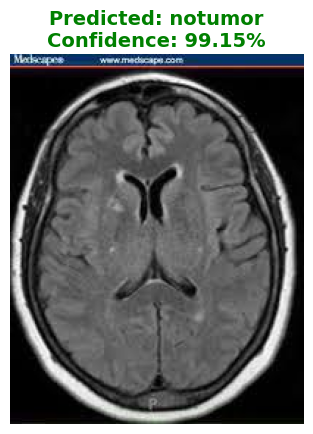


All class probabilities:
  glioma         : 0.15%  
  meningioma     : 0.45%  
  notumor        : 99.15%  ███████████████████████████████████████
  pituitary      : 0.25%  
Actual class: pituitary


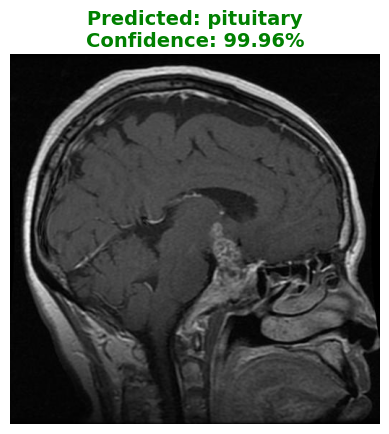


All class probabilities:
  glioma         : 0.01%  
  meningioma     : 0.03%  
  notumor        : 0.00%  
  pituitary      : 99.96%  ███████████████████████████████████████


In [93]:
test_images = {
    'glioma' : '/content/brain_mri/Testing/glioma/Te-gl_103.jpg',
    'meningioma' : '/content/brain_mri/Testing/meningioma/Te-me_100.jpg',
    'notumor' : '/content/brain_mri/Testing/notumor/Te-no_1.jpg',
    'pituitary' : '/content/brain_mri/Testing/pituitary/Te-pi_100.jpg'
}

for actual_class, img_path in test_images.items():
    print(f"Actual class: {actual_class}")
    predict_brain_mri(img_path, brain_mri_model)

Final check before conactenating & GRAD-CAM application

In [95]:
# For brain model
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for inner_layer in reversed(layer.layers):
                if len(inner_layer.output.shape) == 4:
                    return inner_layer.name
        if len(layer.output.shape) == 4:
            return layer.name

print("Brain last conv:", get_last_conv_layer(brain_mri_model))
print("Chest last conv:", get_last_conv_layer(model))

Brain last conv: top_activation
Chest last conv: relu


In [96]:
# Are these your variable names?
print(brain_mri_model.summary())  # brain model
print(model.summary())      # chest model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,756,936 (151.66 MB)

 Trainable params: 13,215,906 (50.41 MB)

 Non-trainable params: 109,216 (426.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 1,338,305 (5.11 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

None


In [98]:
brain_mri_model.save('/content/drive/MyDrive/medical_project/brain_model_final.keras')
model.save('/content/drive/MyDrive/medical_project/chest_model_final.keras')

In [99]:
print(type(brain_mri_model))
print(type(model))

<class 'keras.src.models.sequential.Sequential'>
<class 'keras.src.models.sequential.Sequential'>


In [100]:
print("Brain input:", brain_mri_model.input_shape)
print("Chest input:", model.input_shape)

Brain input: (None, 300, 300, 3)
Chest input: (None, 224, 224, 3)


GRAD-CAM application

In [101]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import efficientnet_v2
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

In [ ]:
# GRAD-CAM core functions
import tensorflow as tf
import numpy as np
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    # Ensure img_array is a Tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # 1. Create a model that outputs the activations of the last convolutional layer
    # The base_conv_model is the first layer of the Sequential model (e.g., EfficientNetV2B3).
    base_conv_model = model.layers[0]

    # Create the feature extraction model: input to last_conv_layer_name
    feature_extractor_model = tf.keras.Model(
        inputs=base_conv_model.input, # Use the input of the base conv model
        outputs=base_conv_model.get_layer(last_conv_layer_name).output
    )

    # 2. Create the classifier model (from the output of last_conv_layer to the final prediction)
    # The input shape for this classifier head will be the output shape of the last_conv_layer.
    classifier_input_shape = feature_extractor_model.output_shape[1:]
    classifier_input = tf.keras.Input(shape=classifier_input_shape)

    # Build the classifier head by taking layers from the original Sequential model
    # that come *after* the base_conv_model.
    x = classifier_input
    for layer in model.layers[1:]: # Iterate through layers after the base_conv_model
        x = layer(x)
    classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        # Pass the input image through the feature extractor to get convolutional features
        # And ensure these features are watched by the tape
        conv_features = feature_extractor_model(img_tensor)
        tape.watch(conv_features)

        # Pass the convolutional features through the classifier to get predictions
        predictions = classifier_model(conv_features)

        # Get the score of the predicted class
        predicted_class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class_idx]

    # Compute gradients of the class score with respect to the convolutional features
    grads = tape.gradient(class_score, conv_features)

    # Perform global average pooling on the gradients and multiply with feature maps to create heatmap.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_features[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap to [0, 1] for visualization.
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    # Also return the original model's predictions for display
    full_model_predictions = model.predict(img_tensor, verbose=0)

    return heatmap.numpy(), full_model_predictions

def overlay_gradcam(img_path, heatmap, target_size):
    img = cv2.imread(img_path)
    img = cv2.resize(img, target_size)
    heatmap_resized = cv2.resize(heatmap, target_size)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    superimposed = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    return superimposed

Model Configration

In [ ]:
MODEL_CONFIG = {
    'brain': {
        'model'           : brain_mri_model,
        'class_labels'    : ['glioma', 'meningioma', 'notumor', 'pituitary'],
        'preprocess_fn'   : efficientnet_v2.preprocess_input,
        'target_size'     : (300, 300),
        'last_conv_layer' : 'top_activation',
        'title'           : 'Brain Tumor MRI Classification'
    },
    'chest': {
        'model'           : model,
        'class_labels'    : ['NORMAL', 'PNEUMONIA'],
        'preprocess_fn'   : densenet_preprocess,
        'target_size'     : (224, 224),
        'last_conv_layer' : 'relu',
        'binary'          : True,
        'title'           : 'Chest X-Ray Classification'
    }
}

In [130]:
def predict_with_gradcam(img_path, modality='brain'):
    config = MODEL_CONFIG[modality]
    model         = config['model']
    class_labels  = config['class_labels']
    target_size   = config['target_size']
    preprocess_fn = config['preprocess_fn']

    # Preprocess — must match training exactly
    img       = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = preprocess_fn(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Ensure the model is built by calling it with a dummy input
    # This is necessary because sometimes model.inputs/model.output are not defined
    # even if model.built is True, when used to construct another model (e.g., grad_model).
    if not model.built:
        dummy_input = np.zeros((1, *target_size, 3))
        _ = model.predict(dummy_input, verbose=0)

    # Grad-CAM
    heatmap, predictions = get_gradcam_heatmap(
        model, img_array, config['last_conv_layer']
    )
    superimposed = overlay_gradcam(img_path, heatmap, target_size)

    # Results
    predicted_idx   = np.argmax(predictions)
    predicted_class = class_labels[predicted_idx]
    confidence      = np.max(predictions) * 100

    # Plot — 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(config['title'], fontsize=15, fontweight='bold')

    # Panel 1 — Original
    axes[0].imshow(image.load_img(img_path))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Panel 2 — Grad-CAM
    axes[1].imshow(superimposed)
    axes[1].set_title('Grad-CAM Heatmap\n(red = high attention)')
    axes[1].axis('off')

    # Panel 3 — Probability bars
    colors = ['#2ecc71' if i == predicted_idx else '#3498db'
              for i in range(len(class_labels))]
    axes[2].barh(class_labels, predictions[0] * 100, color=colors)
    axes[2].set_xlim(0, 100)
    axes[2].set_xlabel('Confidence %')
    axes[2].set_title('Class Probabilities')
    axes[2].axvline(x=70, color='red', linestyle='--', alpha=0.7, label='70% threshold')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n{'='*40}")
    print(f"Modality  : {modality.upper()}")
    print(f"Predicted : {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"{'='*40}")
    print("\nAll class probabilities:")
    for label, prob in zip(class_labels, predictions[0]):
        bar = '█' * int(prob * 30)
        print(f"  {label:15s}: {prob*100:.2f}%  {bar}")

    if confidence < 70:
        print("\n Low confidence — consult a radiologist")

    return predicted_class, confidence

In [ ]:
# Brain MRI — one image from each class
brain_test_images = {
    'glioma'     : '/content/brain_mri/Testing/glioma/Te-gl_155.jpg',
    'meningioma' : '/content/brain_mri/Testing/meningioma/Te-me_224.jpg',
    'notumor'    : '/content/brain_mri/Testing/notumor/Te-no_93.jpg',
    'pituitary'  : '/content/brain_mri/Testing/pituitary/Te-pi_367.jpg',
}

for actual_class, path in brain_test_images.items():
    print(f"\nActual: {actual_class.upper()}")
    config = MODEL_CONFIG['brain']
    predict_with_gradcam(
        path,
        model=config['model'],
        class_labels=config['class_labels'],
        last_conv_layer_name=config['last_conv_layer'],
        preprocess_fn=config['preprocess_fn'],
        target_size=config['target_size'],
        modality='brain',
        binary=config.get('binary', False)
    )

# Chest X-Ray — one image from each class
chest_test_images = {
    'NORMAL'    : '/content/chest_xray/chest_xray/chest_xray/test/NORMAL/IM-0001-0001.jpeg',
    'PNEUMONIA' : '/content/chest_xray/chest_xray/chest_xray/test/PNEUMONIA/person101_bacteria_486.jpeg',
}

for actual_class, path in chest_test_images.items():
    print(f"\nActual: {actual_class.upper()}")
    config = MODEL_CONFIG['chest']
    predict_with_gradcam(
        path,
        model=config['model'],
        class_labels=config['class_labels'],
        last_conv_layer_name=config['last_conv_layer'],
        preprocess_fn=config['preprocess_fn'],
        target_size=config['target_size'],
        modality='chest',
        binary=config.get('binary', False)
    )
